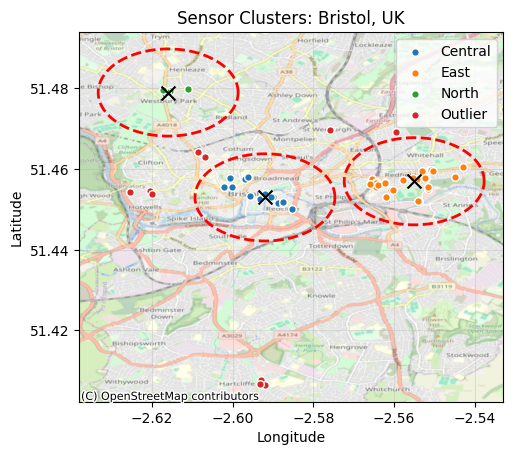

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx # this is the file that handles integrating a map with plt

df = pd.read_csv('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Raw Data/Sensor_Location.csv') # Naturally change this to be your own path

centres = {
    "Central": (-2.592, 51.453), #2
    "East": (-2.555, 51.457), #42
    "North": (-2.616, 51.479) #63
}

mean_lat = df["Latitude"].mean()

lat_to_m = 111000
lon_to_m = 111000 * np.cos(np.deg2rad(mean_lat))

def distance_m(lon1, lat1, lon2, lat2):
    dx = (lon1 - lon2) * lon_to_m
    dy = (lat1 - lat2) * lat_to_m
    return np.sqrt(dx**2 + dy**2)

radius = 1200 

cluster_labels = []

for _, row in df.iterrows():
    distances = {
        name: distance_m(row["Longitude"], row["Latitude"], clon, clat)
        for name, (clon, clat) in centres.items()
    }
    
    closest_cluster = min(distances, key=distances.get)
    
    if distances[closest_cluster] <= radius:
        cluster_labels.append(closest_cluster)
    else:
        cluster_labels.append("Outlier")

df["Cluster"] = cluster_labels

# --- This is a small change to the original that turns the output to a grid plotted on a real map with contextily

for name, group in df.groupby("Cluster"):
    # I've put a white boarder around each marker
    plt.scatter(group["Longitude"], group["Latitude"], label=name, s=30, edgecolors='white', zorder=3)

theta = np.linspace(0, 2*np.pi, 200)

for name, (clon, clat) in centres.items():
    circle_lon = clon + (radius / lon_to_m) * np.cos(theta)
    circle_lat = clat + (radius / lat_to_m) * np.sin(theta)
    
    # I've inclued a small black marker in each sector
    plt.plot(circle_lon, circle_lat, color = 'red', linestyle = '--', linewidth = 2, zorder = 4)
    plt.scatter(clon, clat, marker = "x", color = 'black', s = 100, zorder = 5) 

# This fetches map tiles from openstreetmap
# crs="EPSG:4326" is just the code for the lat/long convention
# alpha is teh "translucentness" of the map
ctx.add_basemap(plt.gca(), crs = "EPSG:4326", source = ctx.providers.OpenStreetMap.Mapnik, alpha =0.8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sensor Clusters: Bristol, UK")
plt.legend()
plt.grid(True, alpha=0.3) # Dimmed grid lines so they don't ruin the map
plt.gca().set_aspect("equal", adjustable="box")
plt.show()


In [24]:
from pathlib import Path

raw_data_dir = Path('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Raw Data')
processed_data_dir = Path('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data')
location_path = raw_data_dir / 'Sensor_Location.csv'
output_path = processed_data_dir / 'all_sensor_data_with_locations_and_clusters.csv'

# Build one big sensor table with location + cluster data
location_with_clusters = pd.read_csv(location_path).copy()

mean_lat = location_with_clusters['Latitude'].mean()
lat_to_m = 111000
lon_to_m = 111000 * np.cos(np.deg2rad(mean_lat))

def distance_m(lon1, lat1, lon2, lat2):
    dx = (lon1 - lon2) * lon_to_m
    dy = (lat1 - lat2) * lat_to_m
    return np.sqrt(dx**2 + dy**2)

cluster_labels = []

for _, row in location_with_clusters.iterrows():
    distances = {
        name: distance_m(row['Longitude'], row['Latitude'], clon, clat)
        for name, (clon, clat) in centres.items()
    }

    closest_cluster = min(distances, key=distances.get)

    if distances[closest_cluster] <= radius:
        cluster_labels.append(closest_cluster)
    else:
        cluster_labels.append('Outlier')

location_with_clusters['Cluster'] = cluster_labels
cluster_number_map = {'Central': 1, 'East': 2, 'North': 3, 'Outlier': 0}
location_with_clusters['ClusterNumber'] = location_with_clusters['Cluster'].map(cluster_number_map)

sensor_files = sorted(
    [path for path in raw_data_dir.glob('*.csv') if path.name != 'Sensor_Location.csv' and path.stem.isdigit()],
    key=lambda path: int(path.stem)
)

sensor_frames = []
for sensor_file in sensor_files:
    sensor_df = pd.read_csv(sensor_file).copy()
    sensor_df.columns = [col.strip() for col in sensor_df.columns]
    sensor_df['SensorNumber'] = int(sensor_file.stem)
    sensor_frames.append(sensor_df)

big_sensor_table = pd.concat(sensor_frames, ignore_index=True, sort=False)
big_sensor_table['date'] = pd.to_datetime(big_sensor_table['date'], errors='coerce')

big_sensor_table = big_sensor_table.merge(
    location_with_clusters[['SensorNumber', 'ClusterNumber', 'Cluster', 'Longitude', 'Latitude']],
    on='SensorNumber',
    how='left'
)

column_order = [
    'SensorNumber', 'ClusterNumber', 'Cluster', 'Longitude', 'Latitude', 'date', 'ped', 'car', 'cyc'
]
big_sensor_table = big_sensor_table[column_order].sort_values(['SensorNumber', 'date']).reset_index(drop=True)
big_sensor_table.to_csv(output_path, index=False)

print(f'Combined {len(sensor_files)} sensor files into {len(big_sensor_table):,} rows.')
print(f'Output saved to: {output_path}')
big_sensor_table.head()


Combined 58 sensor files into 509,472 rows.
Output saved to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv


,SensorNumber,ClusterNumber,Cluster,Longitude,Latitude,date,ped,car,cyc
0,1,1,Central,-2.591538,51.453815,2024-01-01 00:00:00,413,381,9
1,1,1,Central,-2.591538,51.453815,2024-01-01 01:00:00,402,489,10
2,1,1,Central,-2.591538,51.453815,2024-01-01 02:00:00,421,473,10
3,1,1,Central,-2.591538,51.453815,2024-01-01 03:00:00,370,419,4
4,1,1,Central,-2.591538,51.453815,2024-01-01 04:00:00,132,123,2


In [25]:
MIN_ZERO_STREAK_DAYS = 30

# A zero day means the full daily sum of ped + car + cyc is exactly 0.
if 'output_path' not in globals():
    output_path = Path('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv')

if 'big_sensor_table' in globals():
    zero_check_df = big_sensor_table.copy()
else:
    zero_check_df = pd.read_csv(output_path)

zero_check_df['date'] = pd.to_datetime(zero_check_df['date'], errors='coerce')
zero_check_df['day'] = zero_check_df['date'].dt.normalize()
zero_check_df['total_count'] = zero_check_df[['ped', 'car', 'cyc']].fillna(0).sum(axis=1)

daily_totals = (
    zero_check_df.groupby(['SensorNumber', 'Cluster', 'day'], as_index=False)
    .agg(total_count=('total_count', 'sum'))
)
daily_totals['is_zero_day'] = daily_totals['total_count'].eq(0)

streak_rows = []

for sensor_id, sensor_daily in daily_totals.groupby('SensorNumber', sort=True):
    sensor_daily = sensor_daily.sort_values('day').copy()
    sensor_daily['new_streak'] = (
        (~sensor_daily['is_zero_day'])
        | sensor_daily['day'].diff().dt.days.ne(1)
    )
    sensor_daily['streak_group'] = sensor_daily['new_streak'].cumsum()

    zero_days_only = sensor_daily[sensor_daily['is_zero_day']].copy()
    if zero_days_only.empty:
        continue

    sensor_streaks = (
        zero_days_only.groupby('streak_group', as_index=False)
        .agg(
            SensorNumber=('SensorNumber', 'first'),
            Cluster=('Cluster', 'first'),
            start_day=('day', 'min'),
            end_day=('day', 'max'),
            zero_days=('day', 'size')
        )[['SensorNumber', 'Cluster', 'start_day', 'end_day', 'zero_days']]
    )
    streak_rows.append(sensor_streaks)

if streak_rows:
    zero_day_streaks = pd.concat(streak_rows, ignore_index=True)
else:
    zero_day_streaks = pd.DataFrame(
        columns=['SensorNumber', 'Cluster', 'start_day', 'end_day', 'zero_days']
    )

zero_day_streaks = zero_day_streaks[zero_day_streaks['zero_days'] >= MIN_ZERO_STREAK_DAYS]
zero_day_streaks = zero_day_streaks.sort_values(
    ['zero_days', 'SensorNumber', 'start_day'],
    ascending=[False, True, True]
).reset_index(drop=True)

if zero_day_streaks.empty:
    print(f'No sensors have {MIN_ZERO_STREAK_DAYS}+ consecutive zero-count days.')
else:
    sensors_with_zero_runs = sorted(zero_day_streaks['SensorNumber'].unique().tolist())
    print(f'Sensors with {MIN_ZERO_STREAK_DAYS}+ consecutive zero-count days: {sensors_with_zero_runs}')
    print(f'Total sensors flagged: {len(sensors_with_zero_runs)}')
    zero_day_streaks


Sensors with 30+ consecutive zero-count days: [6, 24, 27, 30, 34, 48, 49, 50, 51, 54, 56, 61, 62, 63, 64, 67]
Total sensors flagged: 16


Removed 16 sensors with 30+ consecutive zero-count days.
Sensors remaining on map: 42


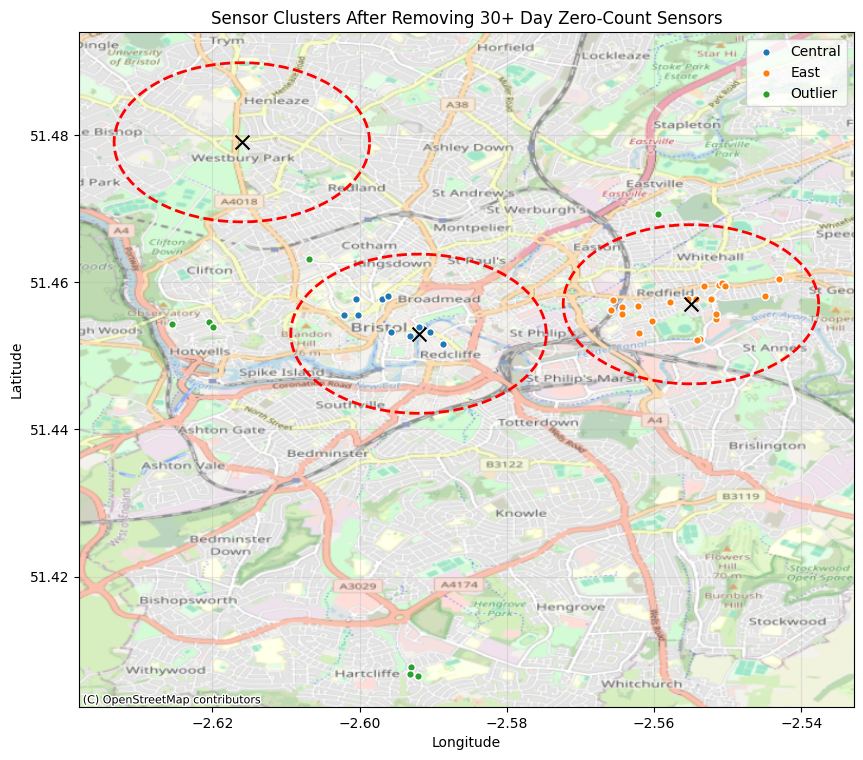

Updated merged table saved to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv
Rows: 509,472 -> 368,928
Sensors: 58 -> 42


In [26]:
MIN_ZERO_STREAK_DAYS = 30

if 'sensors_with_zero_runs' not in globals():
    if 'zero_day_streaks' not in globals():
        raise ValueError('Run the zero-streak cell first so zero_day_streaks is available.')
    sensors_with_zero_runs = sorted(
        zero_day_streaks.loc[zero_day_streaks['zero_days'] >= MIN_ZERO_STREAK_DAYS, 'SensorNumber']
        .unique()
        .tolist()
    )

if 'df' not in globals() or 'Cluster' not in df.columns:
    df = pd.read_csv('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Raw Data/Sensor_Location.csv')
    cluster_labels = []
    for _, row in df.iterrows():
        distances = {
            name: distance_m(row['Longitude'], row['Latitude'], clon, clat)
            for name, (clon, clat) in centres.items()
        }
        closest_cluster = min(distances, key=distances.get)
        if distances[closest_cluster] <= radius:
            cluster_labels.append(closest_cluster)
        else:
            cluster_labels.append('Outlier')
    df['Cluster'] = cluster_labels

filtered_map_df = df[~df['SensorNumber'].isin(sensors_with_zero_runs)].copy()

print(f'Removed {len(sensors_with_zero_runs)} sensors with {MIN_ZERO_STREAK_DAYS}+ consecutive zero-count days.')
print(f'Sensors remaining on map: {len(filtered_map_df)}')

plt.figure(figsize=(10, 10))

for name, group in filtered_map_df.groupby('Cluster'):
    plt.scatter(group['Longitude'], group['Latitude'], label=name, s=30, edgecolors='white', zorder=3)

theta = np.linspace(0, 2*np.pi, 200)

for name, (clon, clat) in centres.items():
    circle_lon = clon + (radius / lon_to_m) * np.cos(theta)
    circle_lat = clat + (radius / lat_to_m) * np.sin(theta)
    plt.plot(circle_lon, circle_lat, color='red', linestyle='--', linewidth=2, zorder=4)
    plt.scatter(clon, clat, marker='x', color='black', s=100, zorder=5)

ctx.add_basemap(plt.gca(), crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Sensor Clusters After Removing {MIN_ZERO_STREAK_DAYS}+ Day Zero-Count Sensors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

if 'output_path' not in globals():
    output_path = Path('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv')

if output_path.exists():
    filtered_table = pd.read_csv(output_path)
elif 'big_sensor_table' in globals():
    filtered_table = big_sensor_table.copy()
else:
    raise ValueError('Run the merged-table cell first so there is a table to filter.')

rows_before = len(filtered_table)
sensors_before = filtered_table['SensorNumber'].nunique()
filtered_table = filtered_table[~filtered_table['SensorNumber'].isin(sensors_with_zero_runs)].copy()
rows_after = len(filtered_table)
sensors_after = filtered_table['SensorNumber'].nunique()

filtered_table.to_csv(output_path, index=False)
big_sensor_table = filtered_table.copy()

print(f'Updated merged table saved to: {output_path}')
print(f'Rows: {rows_before:,} -> {rows_after:,}')
print(f'Sensors: {sensors_before} -> {sensors_after}')


In [27]:
def solar_altitude_deg(dt_utc, lat_deg, lon_deg):
    dts = pd.to_datetime(dt_utc, utc=True)
    n = dts.dt.dayofyear.to_numpy()
    hour = (dts.dt.hour + dts.dt.minute/60.0 + dts.dt.second/3600.0).to_numpy()
    lat = np.deg2rad(lat_deg)
    gamma = 2.0*np.pi/365.0 * (n - 1 + (hour - 12)/24.0)

    decl = (0.006918
            - 0.399912*np.cos(gamma) + 0.070257*np.sin(gamma)
            - 0.006758*np.cos(2*gamma) + 0.000907*np.sin(2*gamma)
            - 0.002697*np.cos(3*gamma) + 0.00148*np.sin(3*gamma))

    eqtime = 229.18*(0.000075
                     + 0.001868*np.cos(gamma) - 0.032077*np.sin(gamma)
                     - 0.014615*np.cos(2*gamma) - 0.040849*np.sin(2*gamma))

    tst = (hour*60.0 + eqtime + 4.0*lon_deg) % 1440.0
    ha = np.deg2rad((tst/4.0) - 180.0)

    cos_zen = np.sin(lat)*np.sin(decl) + np.cos(lat)*np.cos(decl)*np.cos(ha)
    cos_zen = np.clip(cos_zen, -1.0, 1.0)

    zen = np.arccos(cos_zen)
    alt = np.rad2deg(np.pi/2 - zen)
    return alt

In [28]:
if 'output_path' not in globals():
    output_path = Path('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv')

if 'big_sensor_table' in globals():
    light_table = big_sensor_table.copy()
else:
    light_table = pd.read_csv(output_path)

light_table['date'] = pd.to_datetime(light_table['date'], errors='coerce')
light_table['solar_altitude_deg'] = np.nan

for sensor_id, sensor_rows in light_table.groupby('SensorNumber', sort=False):
    lat = float(sensor_rows['Latitude'].iloc[0])
    lon = float(sensor_rows['Longitude'].iloc[0])
    light_table.loc[sensor_rows.index, 'solar_altitude_deg'] = solar_altitude_deg(sensor_rows['date'], lat, lon)

alt = light_table['solar_altitude_deg']
light_table['light_class'] = np.where(
    alt > 0,
    'daylight',
    np.where(alt < -6, 'darkness', 'twilight')
)
light_table['Dark'] = (light_table['light_class'] == 'darkness').astype(int)

preferred_order = [
    'SensorNumber', 'ClusterNumber', 'Cluster', 'Longitude', 'Latitude', 'date',
    'ped', 'car', 'cyc', 'solar_altitude_deg', 'light_class', 'Dark'
]
remaining_columns = [col for col in light_table.columns if col not in preferred_order]
light_table = light_table[preferred_order + remaining_columns]

light_table.to_csv(output_path, index=False)
big_sensor_table = light_table.copy()

print(f'Updated merged table saved to: {output_path}')
print(light_table['light_class'].value_counts(dropna=False))
light_table[['SensorNumber', 'date', 'solar_altitude_deg', 'light_class', 'Dark']].head()


Updated merged table saved to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv
light_class
daylight    184837
darkness    161643
twilight     22448
Name: count, dtype: int64


,SensorNumber,date,solar_altitude_deg,light_class,Dark
0,1,2024-01-01 00:00:00,-61.529806,darkness,1
1,1,2024-01-01 01:00:00,-60.225898,darkness,1
2,1,2024-01-01 02:00:00,-54.953852,darkness,1
3,1,2024-01-01 03:00:00,-47.266506,darkness,1
4,1,2024-01-01 04:00:00,-38.404055,darkness,1


In [30]:
from IPython.display import display

if 'output_path' not in globals():
    output_path = Path('/Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/all_sensor_data_with_locations_and_clusters.csv')

or_df = pd.read_csv(output_path, parse_dates=['date'])
or_df['day'] = or_df['date'].dt.normalize()
or_df['hour'] = or_df['date'].dt.hour.astype(int)

hour_mix = or_df.groupby('hour')['Dark'].agg(['min', 'max', 'mean']).sort_index()
selected_case_hours = [5, 6, 17, 18, 19, 20]
dark_control_hours = [23, 0, 1, 2]
daylight_control_hours = [9, 10, 11, 12, 13, 14]
control_row_specs = [('Dark', hour_value) for hour_value in dark_control_hours] + [('Daylight', hour_value) for hour_value in daylight_control_hours]

for case_hour in selected_case_hours:
    if case_hour not in hour_mix.index or not (hour_mix.loc[case_hour, 'min'] == 0 and hour_mix.loc[case_hour, 'max'] == 1):
        raise ValueError(f'Case hour {case_hour:02d}:00 is not a mixed light/dark hour in the current data.')

for control_hour in dark_control_hours:
    if control_hour not in hour_mix.index or not (hour_mix.loc[control_hour, 'min'] == 1 and hour_mix.loc[control_hour, 'max'] == 1):
        raise ValueError(f'Control hour {control_hour:02d}:00 is not always dark in the current data.')

for control_hour in daylight_control_hours:
    if control_hour not in hour_mix.index or not (hour_mix.loc[control_hour, 'min'] == 0 and hour_mix.loc[control_hour, 'max'] == 0):
        raise ValueError(f'Control hour {control_hour:02d}:00 is not always daylight in the current data.')

def hour_label(hour_value):
    return f'{int(hour_value):02d}:00-{int(hour_value):02d}:59'

# A, B, C, D follow the exact case-control definition you gave.
def compute_case_control_or(cluster_df, outcome, case_h, ctrl_h):
    case_rows = cluster_df.loc[
        cluster_df['hour'] == case_h,
        ['SensorNumber', 'day', 'Dark', outcome]
    ].rename(columns={outcome: 'case_count'})

    ctrl_rows = cluster_df.loc[
        cluster_df['hour'] == ctrl_h,
        ['SensorNumber', 'day', outcome]
    ].rename(columns={outcome: 'control_count'})

    paired = case_rows.merge(ctrl_rows, on=['SensorNumber', 'day'], how='inner')

    A = paired.loc[paired['Dark'] == 0, 'case_count'].sum()
    B = paired.loc[paired['Dark'] == 1, 'case_count'].sum()
    C = paired.loc[paired['Dark'] == 0, 'control_count'].sum()
    D = paired.loc[paired['Dark'] == 1, 'control_count'].sum()

    eps = 1e-9
    R_odds = ((A + eps) / (B + eps)) / ((C + eps) / (D + eps))

    return {
        'A': A,
        'B': B,
        'C': C,
        'D': D,
        'R_odds': R_odds,
        'paired_rows': len(paired),
    }

cluster_order = [cluster for cluster in ['Central', 'East', 'North', 'Outlier'] if cluster in or_df['Cluster'].dropna().unique()]
mode_map = {
    'ped': 'Pedestrians',
    'car': 'Cars',
    'cyc': 'Cyclists',
}

print('Selected case hours:', [hour_label(hour_value) for hour_value in selected_case_hours])
print('Dark control hours:', [hour_label(hour_value) for hour_value in dark_control_hours])
print('Daylight control hours:', [hour_label(hour_value) for hour_value in daylight_control_hours])
print('Clusters included:', cluster_order)
print('Case-hour dark fractions:')
print(hour_mix.loc[selected_case_hours, ['mean']].rename(columns={'mean': 'dark_fraction'}))

case_control_or_tables = {}
case_control_or_long = []

for cluster_name in cluster_order:
    cluster_df = or_df[or_df['Cluster'] == cluster_name].copy()

    for mode_column, mode_name in mode_map.items():
        table = pd.DataFrame(
            index=pd.MultiIndex.from_tuples(
                [(control_type, hour_label(hour_value)) for control_type, hour_value in control_row_specs],
                names=['Control hours', '']
            ),
            columns=pd.MultiIndex.from_product(
                [['Case hours'], [hour_label(hour_value) for hour_value in selected_case_hours]]
            ),
            dtype=float,
        )

        for control_type, ctrl_h in control_row_specs:
            for case_h in selected_case_hours:
                result = compute_case_control_or(cluster_df, mode_column, case_h, ctrl_h)
                table.loc[(control_type, hour_label(ctrl_h)), ('Case hours', hour_label(case_h))] = result['R_odds']

                case_control_or_long.append({
                    'Cluster': cluster_name,
                    'Mode': mode_name,
                    'control_type': control_type,
                    'control_hour': int(ctrl_h),
                    'control_hour_label': hour_label(ctrl_h),
                    'case_hour': int(case_h),
                    'case_hour_label': hour_label(case_h),
                    **result,
                })

        case_control_or_tables[(cluster_name, mode_name)] = table.round(2)

case_control_or_long = pd.DataFrame(case_control_or_long)
case_control_or_path = output_path.parent / 'case_control_hour_or_by_cluster_mode_long.csv'
case_control_or_long.to_csv(case_control_or_path, index=False)

for (cluster_name, mode_name), table in case_control_or_tables.items():
    print('\n' + '=' * 80)
    print(f'{cluster_name} | {mode_name}')
    display(table.style.format('{:.2f}'))

print(f'\nSaved long-form OR results to: {case_control_or_path}')


Selected case hours: ['05:00-05:59', '06:00-06:59', '17:00-17:59', '18:00-18:59', '19:00-19:59', '20:00-20:59']
Dark control hours: ['23:00-23:59', '00:00-00:59', '01:00-01:59', '02:00-02:59']
Daylight control hours: ['09:00-09:59', '10:00-10:59', '11:00-11:59', '12:00-12:59', '13:00-13:59', '14:00-14:59']
Clusters included: ['Central', 'East', 'Outlier']
Case-hour dark fractions:
      dark_fraction
hour               
5          0.576503
6          0.404567
17         0.155738
18         0.351288
19         0.516393
20         0.680328

Central | Pedestrians



Central | Cars



Central | Cyclists



East | Pedestrians



East | Cars



East | Cyclists



Outlier | Pedestrians



Outlier | Cars



Outlier | Cyclists



Saved long-form OR results to: /Users/karandama/Documents/School stuff/Uni Shit/Y2/MDM2/Group-3-MDM/Karan - Notebooks and analysis/Processed Data/case_control_hour_or_by_cluster_mode_long.csv
